## Imports

In [125]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

import spinSimulations.spin as s
from spinSimulations.solver_H import amplitude
from spinSimulations.solver_L import *
from scipy.linalg import expm, null_space
from scipy.integrate import solve_ivp
import copy

## Global setter

In [126]:
# THESE ARE GLOBAL VARS
ss_S = op_S = ppms_S = Js_S = None
ss_C = op_C = ppms_C = Js_C = None

# THIS IS A SETTER FOR THEM
def set_up_spin_system():
    ###################################################
    ### Set up spin system of the free substrate ###
    global ss_S, op_S
    global ppms_S, Js_S
    #global idx_H, idx_D, idx_X
    
    Js_S = np.array(
        [[0]]
    )

    ppms_S = np.array([300])*1e-6

    n_spins = 1

    nuclei_list = ["15N"]

    ss_S = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_S.copy(),
        ppms=ppms_S.copy(),
    )
    
    op_S = ss_S.op

    ###################################################
    ### Set up spin system of the SABRE complex
    global ss_C, op_C
    global ppms_C, Js_C
    #global idx_H, idx_D, idx_X
    
    Js_C = np.array(
            [[0, -7.7, -21],
            [0, 0, 0],
            [0, 0, 0]]
        )

    ppms_C = np.array([-22,-22,250])*1e-6

    n_spins = 3

    nuclei_list = 2 * ["1H"] + ["15N"]

    ss_C = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_C.copy(),
        ppms=ppms_C.copy(),
    )

    op_C = ss_C.op

T1_S = np.array([10])
T1_C = np.array([3,3,5])

set_up_spin_system()

In [127]:
#Density matrix of pure pH2
rho_pH2=np.array([[0,0,0,0],[0,0.5,-0.5,0],[0,-0.5,0.5,0],[0,0,0,0]]) 


def SABRE_SO(ss_S, ss_C, B0, kd, W):
    #Generate partial trace superoperator
    Tr = part_trace_SO(ss_S,ss_C)
  
    #Generate Kronecker product superoperator
    Kron = kron_SO(ss_S,ss_C,rho_pH2)

    #Calculate relaxation superoperator of the substrate
    R_S = relax_phenom_SO(ss_S, T1_S)
    #Calculate Hamiltonian of the substrate
    ham_S = ss_S.build_ham_lab(field=B0, ZULF = True)

    #Generate the Liouvillian of the substrate
    L_S = -1j*comm_SO(ham_S)+R_S

    #Calculate relaxation superoperator of the complex
    R_C = relax_phenom_SO(ss_C, T1_C)
    #Calculate Hamiltonian superoperator of the complex
    ham_C = ss_C.build_ham_lab(field=B0, ZULF = True)

    #Generate Liouvillian of the complex
    L_C = -1j*comm_SO(ham_C)+R_C

    #Generate SABRE matrix for the composite system
    M = np.block([[L_S-kd*W*np.eye(ss_S.get_spin_dim()**2), kd*Tr],[kd*W*Kron, L_C-kd*np.eye(ss_C.get_spin_dim()**2)]])

    return M


## Field dependence

In [128]:
kd = 20
W = 0.1
B0 = np.linspace(-5e-6,5e-6,200)

P_1 = np.empty(len(B0))
obs = ss_S.pol_level(0)

for i,b in enumerate(B0):
    #Set the magnetic field 
    M_SABRE = SABRE_SO(ss_S, ss_C, b, kd, W)
    
    #Calculate the steady state of the system
    sigma = null_space(M_SABRE)                         #Calculate the null space of the coefficient matrix
    sigma = sigma[:ss_S.get_spin_dim()**2]
    sigma = vec2mat(sigma)

    #Normalize the steady-state density operator
    sigma = sigma / np.trace(sigma)

    #Calculate the polarization level
    P_1[i]=np.real(amplitude(obs, sigma))

Text(0.5, 1.0, 'SABRE-SHEATH field dependence')

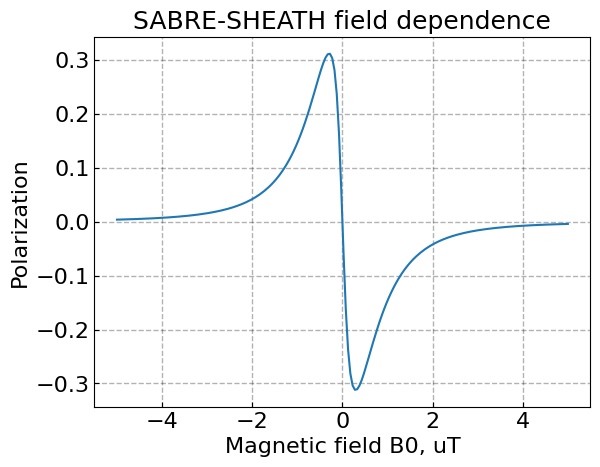

In [129]:
fig, (ax1) = plt.subplots(nrows=1)

ax1.plot(B0*1e+6,P_1)

ax1.tick_params( axis='both', which='major', labelsize=16,direction='in')

ax1.grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
ax1.grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

ax1.set_xlabel('Magnetic field B0, uT',fontsize=16)
ax1.set_ylabel('Polarization',fontsize=16)
ax1.set_title('SABRE-SHEATH field dependence',fontsize=18)


## Polarization build-up

In [130]:
# Set magnetic field for polariztion transfer in T
B0 = 0.3*1e-6

M_SABRE = SABRE_SO(ss_S, ss_C, B0, kd, W)

rho_S=np.eye(ss_S.get_spin_dim(), dtype = np.complex128) #Non polarized density matrix for substrate
rho_S=rho_S/np.trace(rho_S)
rho_C=np.eye(ss_C.get_spin_dim(), dtype = np.complex128)  #Non polarized density matrix for complex
rho_C=rho_C/np.trace(rho_C)
#Density matrices -> concentration normalized density matrices
S_conc=1
C_conc=1*W
sigma_S = S_conc*rho_S 
sigma_C = C_conc*rho_C 

#Flatten in column-major (Fortran- style) order
sigma_S = mat2vec(sigma_S)
sigma_C = mat2vec(sigma_C)

sigma_0 = np.hstack([sigma_S, sigma_C])

# Generate the observables
obs_S = ss_S.pol_level(0)
obs_S = mat2vec(obs_S)
obs_C = ss_C.pol_level(2)
obs_C = mat2vec(obs_C)

In [131]:
#Calculation with numerical integration
def rhs(t,y): return M_SABRE @ y
t_start=0
t_end=10
sol=solve_ivp(rhs,[0,10],sigma_0,t_eval=np.linspace(t_start,t_end,10000),method='RK23')

#Calculate the polarization level
P_S=amplitude_v(obs_S, sol.y[:ss_S.get_spin_dim()**2,:]) ## 15N polarization in the substrate 
P_C=amplitude_v(obs_C, sol.y[ss_S.get_spin_dim()**2:ss_S.get_spin_dim()**2+ss_C.get_spin_dim()**2,:]) ## 15N polarization in the substrate 

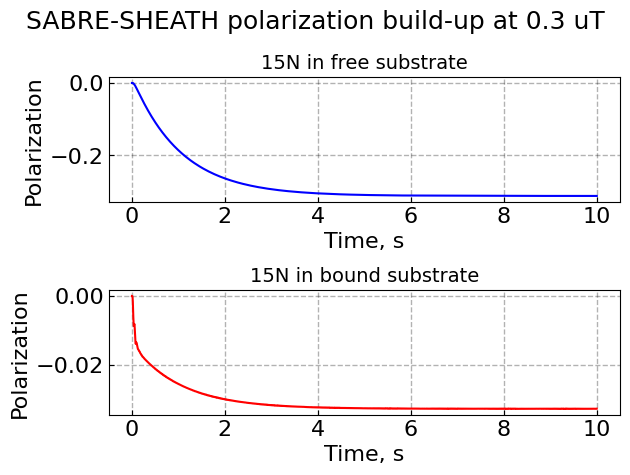

In [132]:
fig, (ax1) = plt.subplots(nrows=2)

ax1[0].plot(sol.t,P_S, 'b')
ax1[0].set_title("15N in free substrate",fontsize=14)
ax1[1].plot(sol.t,P_C, 'r')
ax1[1].set_title("15N in bound substrate",fontsize=14)
for i in range(2):
    ax1[i].set_xlabel('Time, s',fontsize=16)

    ax1[i].set_ylabel('Polarization',fontsize=16)

    ax1[i].tick_params( axis='both', which='major', labelsize=16,direction='in')

    ax1[i].grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
    ax1[i].grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

fig.suptitle(f"SABRE-SHEATH polarization build-up at {B0*1e+6} uT",fontsize=18)
plt.tight_layout()